In [121]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [122]:
from model.metrics import logloss,evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid
import matplotlib.pyplot as plt
from model.linear_model import LinearModel

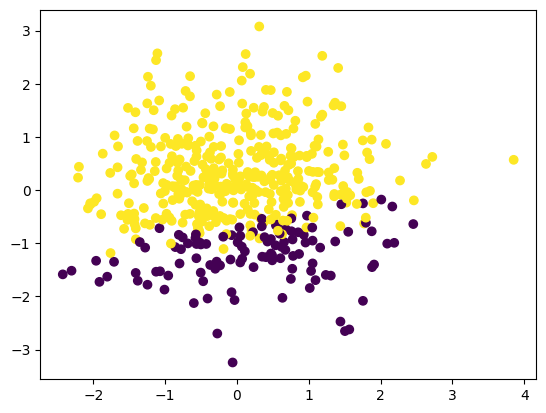

In [123]:
# Sample Code for generating datasets
size = 500
dim=2
noise_bound = 0.2

seed = 42
np.random.seed(seed)

X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=False)
plt.scatter(X[:,1],X[:,2],c=y)

## Functions

In [124]:
# # loading data
# loaded_data = np.load(f'data/logistic_data/logistic_data_A.npz')

# X = loaded_data['X_data']
# y = loaded_data['y_data']
# W = loaded_data['W_data']

# # Show the size of data
# print(f"X size : {X.shape}, y size : {y.shape}")

# # Make sure size and dim correct.
# size = X.shape[0]
# dim = X.shape[1]-1

def load_data(tgt_data):
    # loading data
    loaded_data = np.load(f'data/logistic_data/logistic_data_{tgt_data}.npz')

    X = loaded_data['X_data']
    y = loaded_data['y_data']
    W = loaded_data['W_data']

    # Show the size of data
    print(f"X size : {X.shape}, y size : {y.shape}")

    # Make sure size and dim correct.
    size = X.shape[0]
    dim = X.shape[1]-1

    return X, y, W, size, dim

# RANDOM SEED DECLEARED HERE
seed = 42 # do not change the seed
np.random.seed(seed)

def train_model(tgt_data, lr=0.01, n_iteration=500, val_ratio=0.2, draw_scatter=False):
    X, y, W, size, dim = load_data(tgt_data)

    # Setting loss function, gradient, and activation function.
    loss_fn = logloss
    act_fn = sigmoid
    grad_fn = logloss_sigmoid_grad

    #Split dataset to train dataset and validation dataset
    X_train,y_train,X_val,y_val = get_train_val(X,y)

    # Setting model and starting training
    model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
    model.fit(X_train,y_train,lr=lr,n_iteration = n_iteration,val_ratio=0.2)

    # Predicting on validation dataset
    y_val_pred = model.predict(X_val)
    # evaluate model performance
    evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}')

    if (draw_scatter):
        # Plot
        x_min, x_max = X_val[:, 1].min(), X_val[:, 1].max()
        y_min, y_max = X_val[:, 2].min(), X_val[:, 2].max()

        # Add a small margin so points/boundary are not flush with axes
        x_margin = 0.05 * (x_max - x_min)
        y_margin = 0.05 * (y_max - y_min)

        x_plot_min, x_plot_max = x_min - x_margin, x_max + x_margin
        y_plot_min, y_plot_max = y_min - y_margin, y_max + y_margin
        plt.figure(figsize=(4, 3))
        plt.scatter(X_val[:, 1], X_val[:, 2], c=y_val)

        # Decision boundary from model weights: w0 + w1*x1 + w2*x2 = 0
        ex1 = np.linspace(x_plot_min, x_plot_max, 200)
        ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]
        plt.plot(ex1, ex2, color='r', label='decision boundary')
        plt.xlim(x_plot_min, x_plot_max)
        plt.ylim(y_plot_min, y_plot_max)
        plt.legend()
        plt.show()

### Logistic dataset A
#### lr = 0.1

X size : (2000, 3), y size : (2000,)
50. Training loss: 0.42788681156341524, Val loss:0.4289337233194825
100. Training loss: 0.31865436882587583, Val loss:0.330744022589277
150. Training loss: 0.2756136848389012, Val loss:0.29183663203624455
200. Training loss: 0.2515647449518196, Val loss:0.27001137334938924
250. Training loss: 0.23586370599134487, Val loss:0.2557354638551537
300. Training loss: 0.22467783764966348, Val loss:0.2455615161221097
350. Training loss: 0.21624915555159707, Val loss:0.2379013150251245
400. Training loss: 0.20964409595419928, Val loss:0.23190816484103666
450. Training loss: 0.2043156331315366, Val loss:0.2270843249497499
500. Training loss: 0.19991967899618934, Val loss:0.22311586759002253


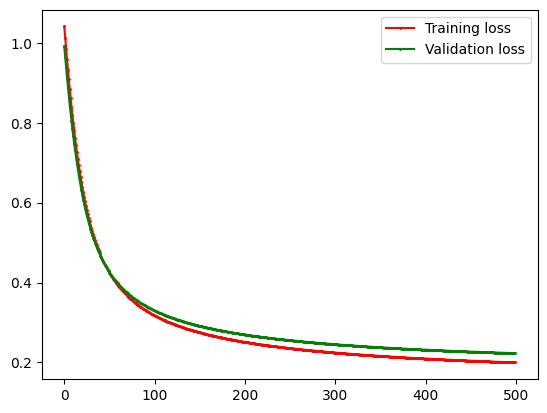

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.9050
Precision : 0.9087
Recall    : 0.9171
F1-score  : 0.9128


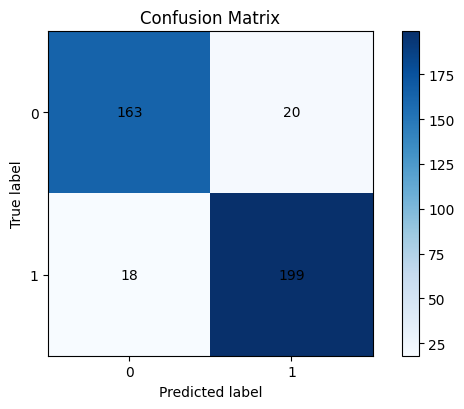

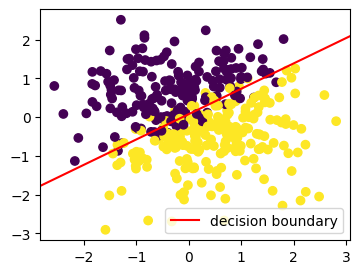

In [125]:
train_model(tgt_data="A",lr=0.1,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.01

X size : (2000, 3), y size : (2000,)
50. Training loss: 0.7454599199175629, Val loss:0.7289685925005063
100. Training loss: 0.6684052041410405, Val loss:0.6557916620079433
150. Training loss: 0.6059713143040598, Val loss:0.5968876243482448
200. Training loss: 0.5555295112853988, Val loss:0.549603760496019
250. Training loss: 0.5146553927944147, Val loss:0.511512440527537
300. Training loss: 0.48129087814211313, Val loss:0.48057462242897986
350. Training loss: 0.4537813804466344, Val loss:0.4551703908054428
400. Training loss: 0.4308398665504119, Val loss:0.4340540530785389
450. Training loss: 0.4114822647561788, Val loss:0.41628271608980655
500. Training loss: 0.39496076529806007, Val loss:0.4011459118872098


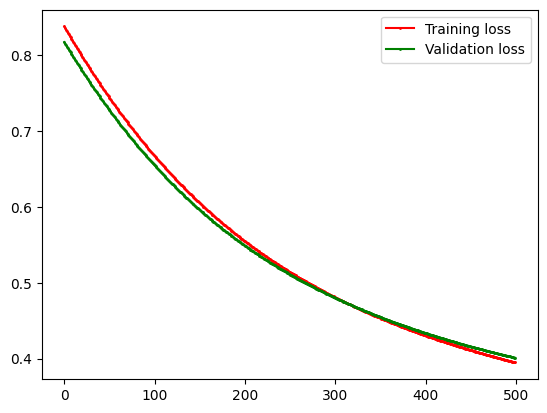

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.8775
Precision : 0.8784
Recall    : 0.8986
F1-score  : 0.8884


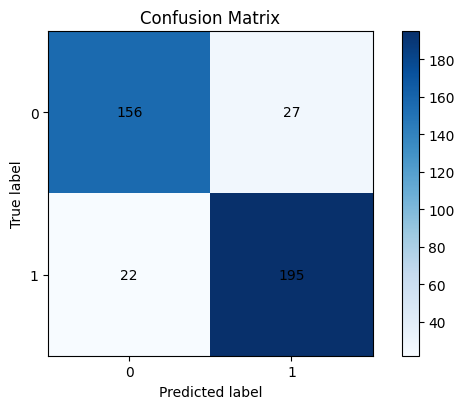

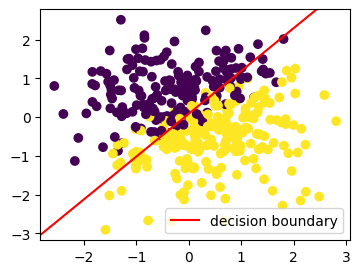

In [126]:
train_model(tgt_data="A",lr=0.01,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.001

X size : (2000, 3), y size : (2000,)
50. Training loss: 0.7093169445425765, Val loss:0.7045797723436771
100. Training loss: 0.7014838993048842, Val loss:0.6969548519437974
150. Training loss: 0.6938374304922718, Val loss:0.6895152134152447
200. Training loss: 0.6863731929864687, Val loss:0.6822564955015082
250. Training loss: 0.6790868552162503, Val loss:0.6751743498609324
300. Training loss: 0.6719741079220394, Val loss:0.6682644500316822
350. Training loss: 0.665030672285564, Val loss:0.6615224997485935
400. Training loss: 0.6582523074176521, Val loss:0.6549442406047219
450. Training loss: 0.6516348172040537, Val loss:0.6485254590573621
500. Training loss: 0.6451740565153343, Val loss:0.6422619927845884


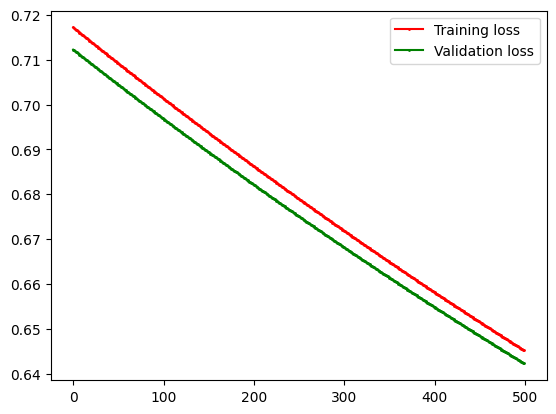

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.7000
Precision : 0.7156
Recall    : 0.7419
F1-score  : 0.7285


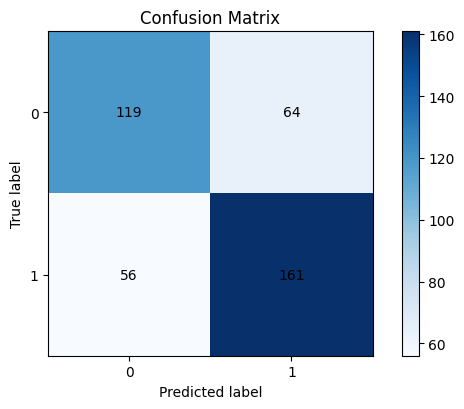

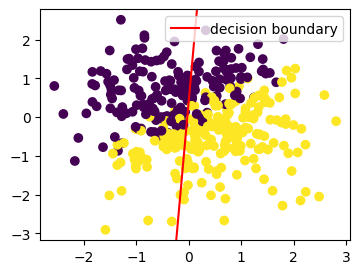

In [127]:
train_model(tgt_data="A",lr=0.001,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

### (A) Different number of iterations under lr = 0.01
#### 500 iterations

X size : (2000, 3), y size : (2000,)
50. Training loss: 0.9147723751543744, Val loss:0.8986536364012234
100. Training loss: 0.8024150594793481, Val loss:0.7898998018327938
150. Training loss: 0.7124642866676678, Val loss:0.7032122471327961
200. Training loss: 0.6412705870842887, Val loss:0.6349450291534765
250. Training loss: 0.584947213835852, Val loss:0.5812202913361195
300. Training loss: 0.5400371280553775, Val loss:0.5386001379363522
350. Training loss: 0.5037721385830725, Val loss:0.5043447435239461
400. Training loss: 0.4740574795337542, Val loss:0.4763924806815177
450. Training loss: 0.4493476276880288, Val loss:0.45323128576325866
500. Training loss: 0.4285096054269051, Val loss:0.4337591225545644


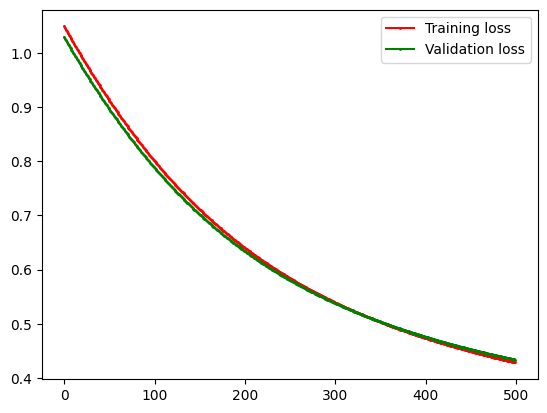

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.9025
Precision : 0.8938
Recall    : 0.9309
F1-score  : 0.9120


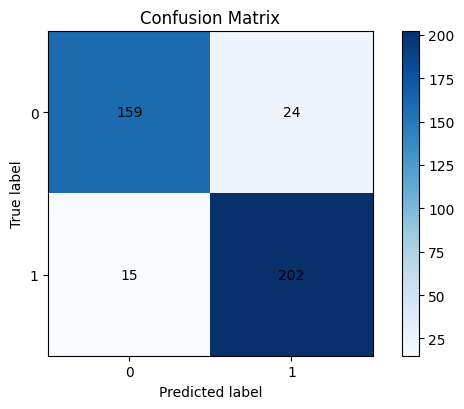

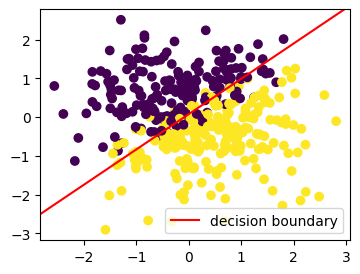

In [128]:
train_model(tgt_data="A",lr=0.01,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### 1000 iterations

X size : (2000, 3), y size : (2000,)
50. Training loss: 0.7933766559806992, Val loss:0.7756178626393787
100. Training loss: 0.7069013808208238, Val loss:0.6931295032676825
150. Training loss: 0.6369937771999477, Val loss:0.6268499753293877
200. Training loss: 0.5807723999057736, Val loss:0.5738803998852517
250. Training loss: 0.5354809818346344, Val loss:0.5314613772863425
300. Training loss: 0.4987403769386377, Val loss:0.49723052483240116
350. Training loss: 0.4686286859396452, Val loss:0.4692987983892709
400. Training loss: 0.44365409804904055, Val loss:0.4462151911019686
450. Training loss: 0.42268253216779206, Val loss:0.4268872492820387
500. Training loss: 0.40485851561690434, Val loss:0.4104977722209508
550. Training loss: 0.38953629737393347, Val loss:0.39643424048910214
600. Training loss: 0.37622560986546133, Val loss:0.3842343621242719
650. Training loss: 0.36455100389384876, Val loss:0.3735458711446835
700. Training loss: 0.35422204710186367, Val loss:0.36409741767790615
75

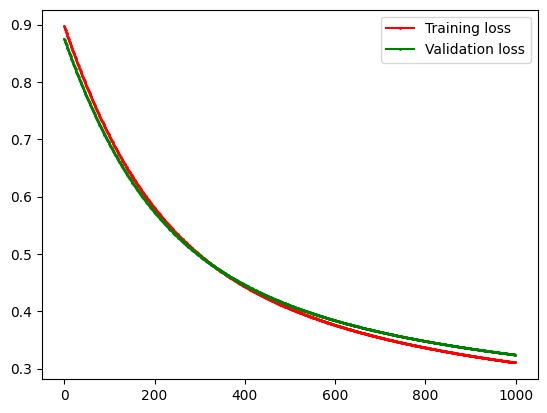

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.9025
Precision : 0.9045
Recall    : 0.9171
F1-score  : 0.9108


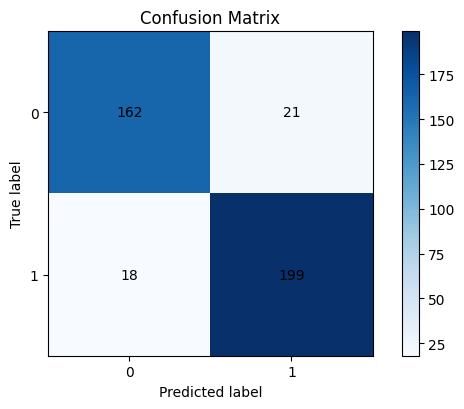

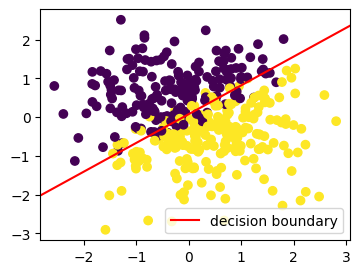

In [129]:
train_model(tgt_data="A",lr=0.01,n_iteration = 1000,val_ratio=0.2,draw_scatter=True)

#### 1500 iterations

X size : (2000, 3), y size : (2000,)
50. Training loss: 0.9661447248679093, Val loss:0.9484023825174891
100. Training loss: 0.8441354009383403, Val loss:0.8301528268183322
150. Training loss: 0.7456933541831955, Val loss:0.7351251145821522
200. Training loss: 0.6675269118371464, Val loss:0.6600315449691629
250. Training loss: 0.6057457665428199, Val loss:0.6009880558224516
300. Training loss: 0.556672973283416, Val loss:0.5543330550333913
350. Training loss: 0.5172591602184023, Val loss:0.5170427474378174
400. Training loss: 0.485154517648333, Val loss:0.48679955042244155
450. Training loss: 0.45861245194980577, Val loss:0.46189096948534464
500. Training loss: 0.43635126644863753, Val loss:0.4410677365736161
550. Training loss: 0.417429744639117, Val loss:0.42341757763214927
600. Training loss: 0.40115110895205763, Val loss:0.4082686187106327
650. Training loss: 0.38699346893086617, Val loss:0.3951199739746957
700. Training loss: 0.3745607271706332, Val loss:0.38359308914117957
750. Tr

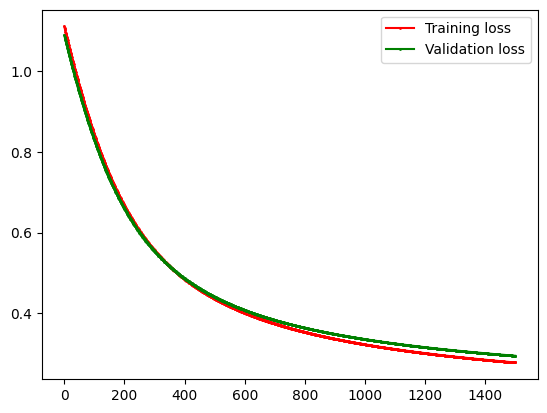

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.9025
Precision : 0.9083
Recall    : 0.9124
F1-score  : 0.9103


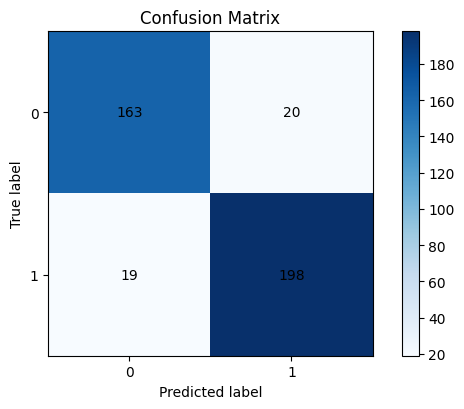

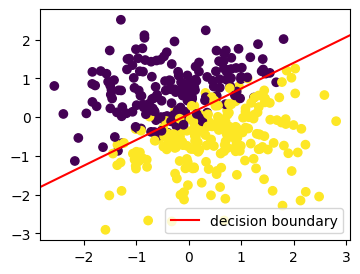

In [130]:
train_model(tgt_data="A",lr=0.01,n_iteration = 1500,val_ratio=0.2,draw_scatter=True)

### Logistic dataset B
#### lr = 0.1

X size : (2000, 3), y size : (2000,)
50. Training loss: 0.465383649373244, Val loss:0.4661234000232941
100. Training loss: 0.42403229154643396, Val loss:0.4256692199274806
150. Training loss: 0.4100617616551343, Val loss:0.41157770232929425
200. Training loss: 0.40371982923133476, Val loss:0.4050556557856921
250. Training loss: 0.4004057968290689, Val loss:0.4015932785783212
300. Training loss: 0.3985339057905059, Val loss:0.3996044305455018
350. Training loss: 0.39742405908458067, Val loss:0.39840097311617606
400. Training loss: 0.39674406340152973, Val loss:0.3976446433092124
450. Training loss: 0.39631752827151223, Val loss:0.3971550636696513
500. Training loss: 0.3960452695941153, Val loss:0.3968303701008594


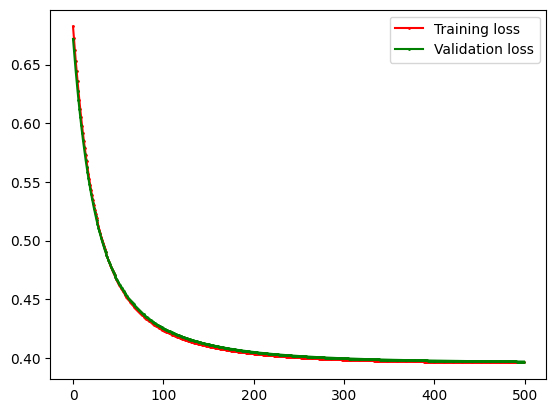

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.7800
Precision : 0.7793
Recall    : 0.8160
F1-score  : 0.7972


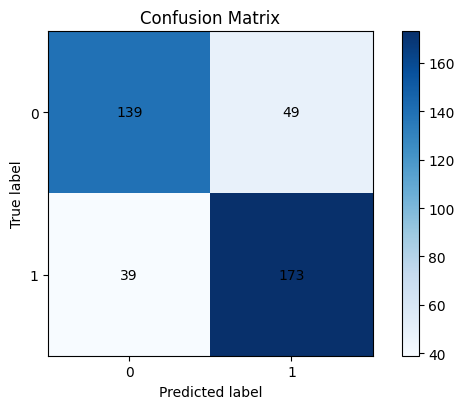

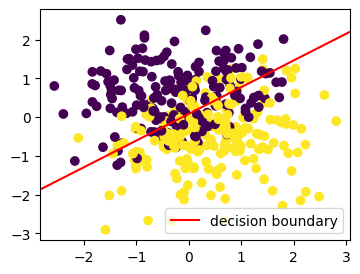

In [131]:
train_model(tgt_data="B",lr=0.1,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.01

X size : (2000, 3), y size : (2000,)
50. Training loss: 0.6645786775772594, Val loss:0.6627718792567079
100. Training loss: 0.6221012594824996, Val loss:0.6206588539252025
150. Training loss: 0.588466630908476, Val loss:0.5873688413533876
200. Training loss: 0.561569695372645, Val loss:0.5607878350701083
250. Training loss: 0.539806746382598, Val loss:0.5393080764906
300. Training loss: 0.5219821014532916, Val loss:0.5217333877327064
350. Training loss: 0.5072096492057234, Val loss:0.5071793179068484
400. Training loss: 0.4948307068740288, Val loss:0.49498992927895086
450. Training loss: 0.4843517164114976, Val loss:0.48467480134407237
500. Training loss: 0.4753989475706559, Val loss:0.4758633364900568


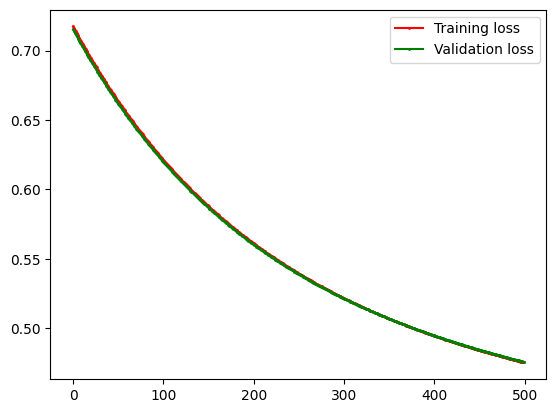

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.7775
Precision : 0.7783
Recall    : 0.8113
F1-score  : 0.7945


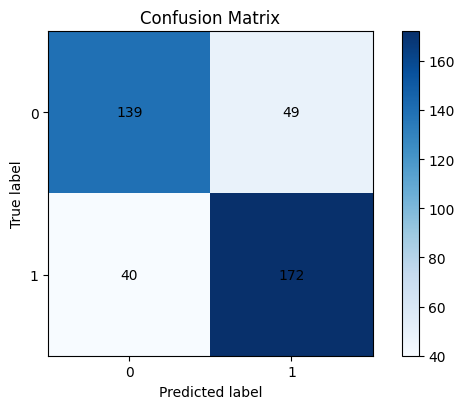

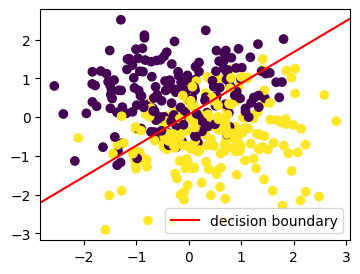

In [132]:
train_model(tgt_data="B",lr=0.01,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.001

X size : (2000, 3), y size : (2000,)
50. Training loss: 0.8150065348897538, Val loss:0.8126388661921545
100. Training loss: 0.8069373318224585, Val loss:0.8046198719470006
150. Training loss: 0.7990384805067228, Val loss:0.7967707623751236
200. Training loss: 0.7913076902252778, Val loss:0.7890892808698009
250. Training loss: 0.7837426044156925, Val loss:0.7815731019486157
300. Training loss: 0.7763408060586908, Val loss:0.7742198366923714
350. Training loss: 0.7690998231155741, Val loss:0.7670270382452469
400. Training loss: 0.7620171339862678, Val loss:0.7599922073470124
450. Training loss: 0.7550901729603049, Val loss:0.7531127978688812
500. Training loss: 0.7483163356341305, Val loss:0.7463862223255523


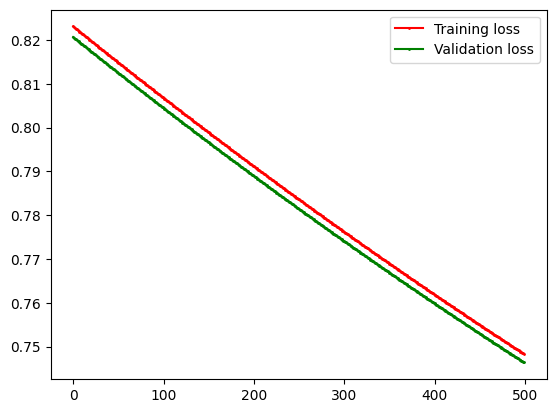

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.4625
Precision : 0.4933
Recall    : 0.5236
F1-score  : 0.5080


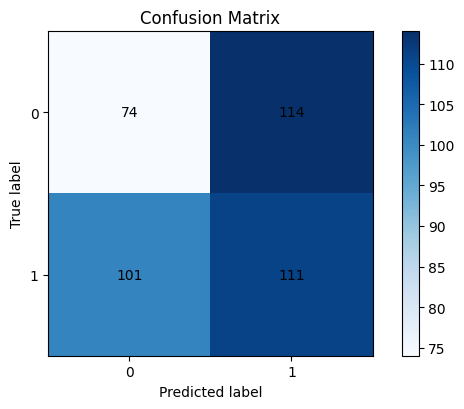

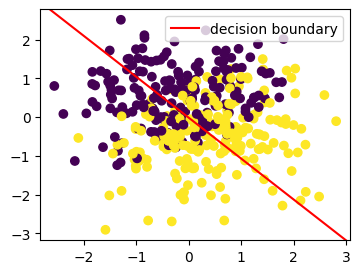

In [133]:
train_model(tgt_data="B",lr=0.001,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

### (B) Different number of iterations under lr = 0.01
#### 500 iterations

X size : (2000, 3), y size : (2000,)
50. Training loss: 0.6708627378894989, Val loss:0.6687415130141058
100. Training loss: 0.6268589431238107, Val loss:0.6253562636772056
150. Training loss: 0.591821373651424, Val loss:0.5908608187872121
200. Training loss: 0.5637584181348101, Val loss:0.5632617804911663
250. Training loss: 0.5410830930857716, Val loss:0.5409756783289132
300. Training loss: 0.5225722753896347, Val loss:0.5227866647596905
350. Training loss: 0.5072986706274891, Val loss:0.5077764031257328
400. Training loss: 0.49456296243910297, Val loss:0.49525466627487075
450. Training loss: 0.4838368197013388, Val loss:0.48470148211525155
500. Training loss: 0.4747186813410842, Val loss:0.47572256402358803


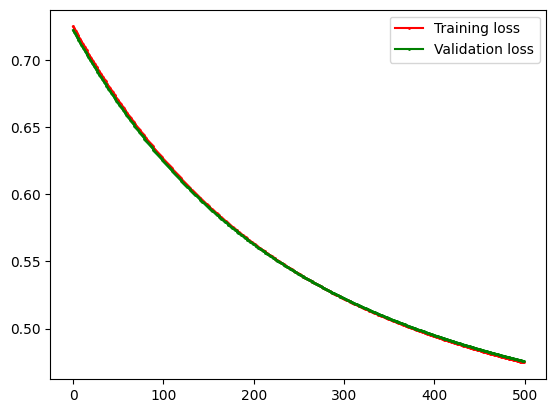

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.7850
Precision : 0.7788
Recall    : 0.8302
F1-score  : 0.8037


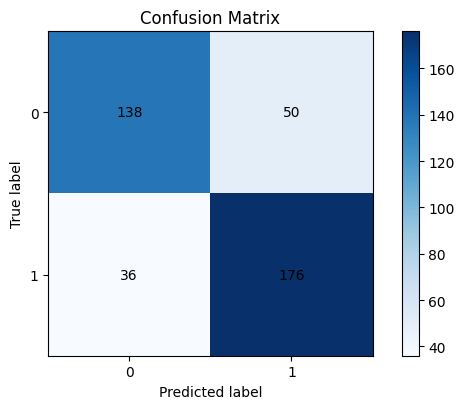

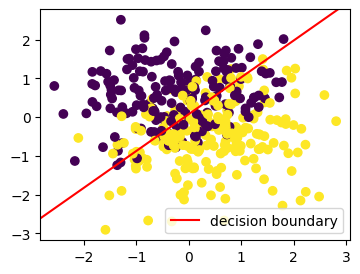

In [134]:
train_model(tgt_data="B",lr=0.01,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### 1000 iterations

X size : (2000, 3), y size : (2000,)
50. Training loss: 0.6225753202367488, Val loss:0.6213889099379575
100. Training loss: 0.5880891613333787, Val loss:0.587476593464701
150. Training loss: 0.5603663559114374, Val loss:0.5602439567379175
200. Training loss: 0.537926401990405, Val loss:0.5382111043678386
250. Training loss: 0.5196031388305434, Val loss:0.5202187048731791
300. Training loss: 0.5044969662397387, Val loss:0.5053770461053849
350. Training loss: 0.4919205272813164, Val loss:0.4930093468442305
400. Training loss: 0.48134965038267624, Val loss:0.48260135019930833
450. Training loss: 0.4723834123914902, Val loss:0.47376079969197366
500. Training loss: 0.46471331365978596, Val loss:0.46618647452767636
550. Training loss: 0.4581001296718557, Val loss:0.45964512199529645
600. Training loss: 0.4523567481821347, Val loss:0.45395446294715425
650. Training loss: 0.4473354963023298, Val loss:0.4489707062131936
700. Training loss: 0.44291877238470895, Val loss:0.4445793556160793
750. T

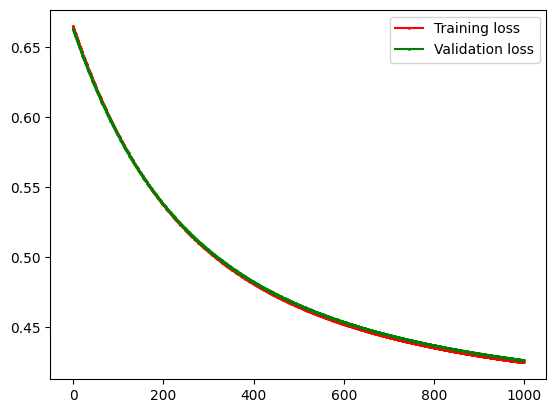

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.7775
Precision : 0.7783
Recall    : 0.8113
F1-score  : 0.7945


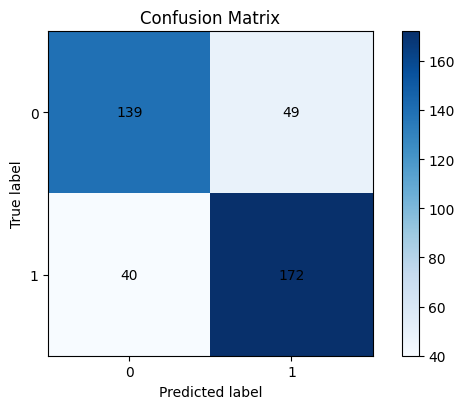

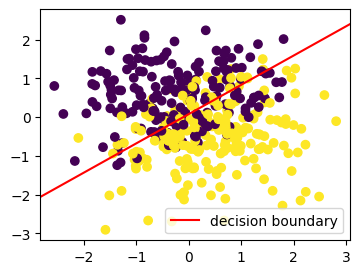

In [135]:
train_model(tgt_data="B",lr=0.01,n_iteration = 1000,val_ratio=0.2,draw_scatter=True)

#### 1500 iterations

X size : (2000, 3), y size : (2000,)
50. Training loss: 0.70267552334721, Val loss:0.7001879725491635
100. Training loss: 0.6521205519685286, Val loss:0.6502213746225122
150. Training loss: 0.6120920328288113, Val loss:0.610718692365923
200. Training loss: 0.580238659245196, Val loss:0.5793256311473518
250. Training loss: 0.554667296093792, Val loss:0.5541497568318323
300. Training loss: 0.5339184429898907, Val loss:0.5337358609694922
350. Training loss: 0.5168910772553232, Val loss:0.5169893738426964
400. Training loss: 0.502760905780178, Val loss:0.5030932110922469
450. Training loss: 0.4909101411772456, Val loss:0.4914366179646077
500. Training loss: 0.48087290183175846, Val loss:0.4815600886668839
550. Training loss: 0.4722947061390423, Val loss:0.4731146825065907
600. Training loss: 0.46490304891549705, Val loss:0.46583259107945657
650. Training loss: 0.4584861787777085, Val loss:0.4595059867353443
700. Training loss: 0.4528777787774539, Val loss:0.45397180397406556
750. Training 

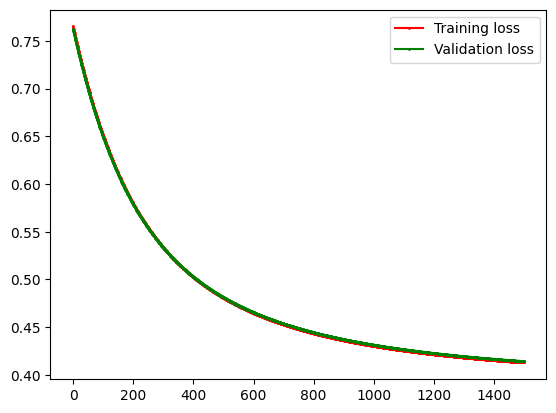

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.7775
Precision : 0.7783
Recall    : 0.8113
F1-score  : 0.7945


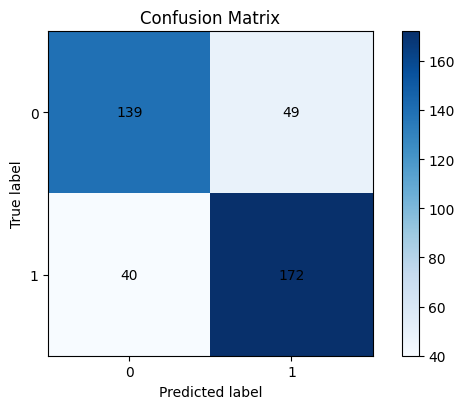

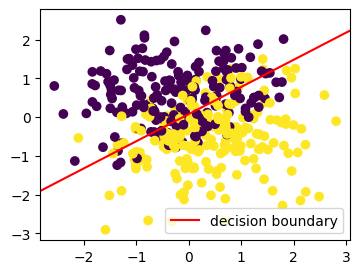

In [136]:
train_model(tgt_data="B",lr=0.01,n_iteration = 1500,val_ratio=0.2,draw_scatter=True)

### Logistic dataset C
#### lr = 0.1`

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.3207129862933561, Val loss:0.3334892220718658
100. Training loss: 0.2561540810286647, Val loss:0.27253129436997925
150. Training loss: 0.22416841664903348, Val loss:0.24143264155108307
200. Training loss: 0.20371697180426937, Val loss:0.22117355861059482
250. Training loss: 0.1890045881379793, Val loss:0.2064153628125906
300. Training loss: 0.17769841350170829, Val loss:0.1949710883504578
350. Training loss: 0.16863140490033784, Val loss:0.18572988986948957
400. Training loss: 0.16113720043621238, Val loss:0.17804949859094021
450. Training loss: 0.15480073442192097, Val loss:0.17152582151429002
500. Training loss: 0.14934704793767867, Val loss:0.16588900931946485


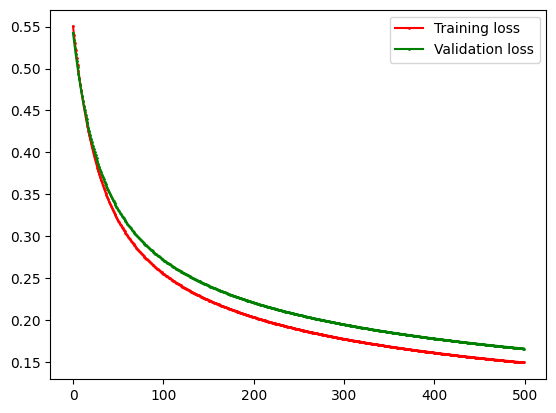

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.9762
Precision : 0.9852
Recall    : 0.9719
F1-score  : 0.9785


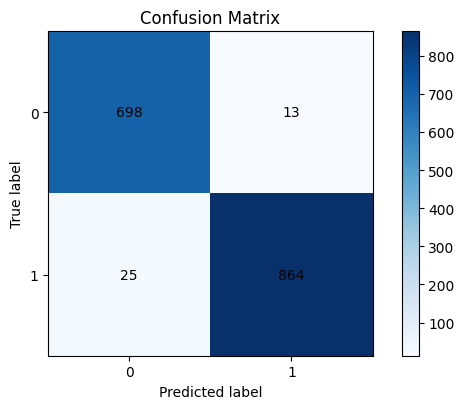

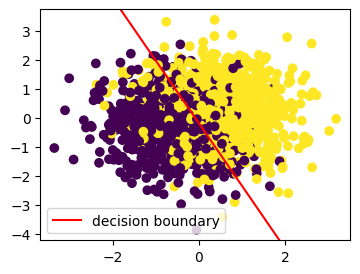

In [137]:
train_model(tgt_data="C",lr=0.1,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.01

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.6629485270422599, Val loss:0.6610767352448397
100. Training loss: 0.5970689866240273, Val loss:0.5991300475257706
150. Training loss: 0.5434704750015893, Val loss:0.5486712185657903
200. Training loss: 0.4998145127722962, Val loss:0.5075155606539306
250. Training loss: 0.46406451602112286, Val loss:0.473760386676902
300. Training loss: 0.4345452354994485, Val loss:0.44583654281933727
350. Training loss: 0.40992636498343255, Val loss:0.422496592807393
400. Training loss: 0.38917236531174454, Val loss:0.4027705363258544
450. Training loss: 0.3714847810082208, Val loss:0.38591207667081284
500. Training loss: 0.3562495148560956, Val loss:0.37134845708213066


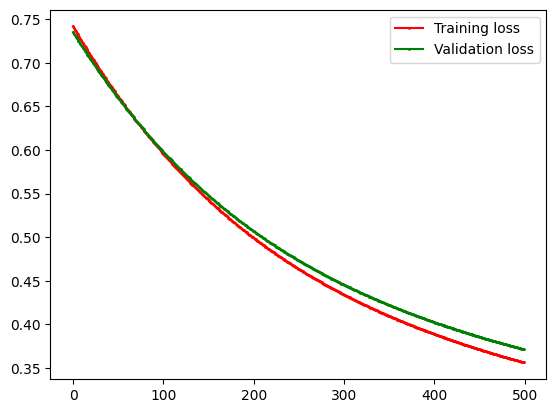

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.9019
Precision : 0.9207
Recall    : 0.9010
F1-score  : 0.9107


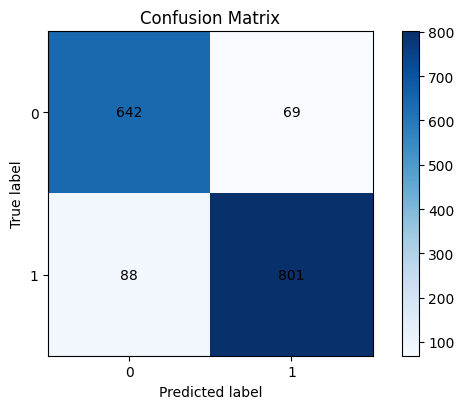

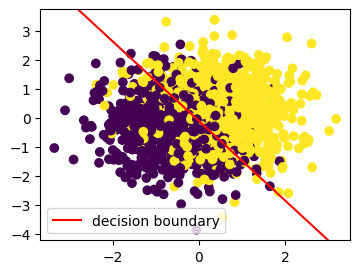

In [138]:
train_model(tgt_data="C",lr=0.01,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.001

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.5157110404156487, Val loss:0.5300048107742953
100. Training loss: 0.511430292082127, Val loss:0.5258595314060864
150. Training loss: 0.5072264181037616, Val loss:0.5217882469989362
200. Training loss: 0.5030979804401065, Val loss:0.5177895639299017
250. Training loss: 0.4990435592029243, Val loss:0.5138621053596386
300. Training loss: 0.49506175298864685, Val loss:0.5100045117152789
350. Training loss: 0.4911511791736377, Val loss:0.506215441132919
400. Training loss: 0.48731047417376994, Val loss:0.5024935698592032
450. Training loss: 0.48353829366982215, Val loss:0.49883759261178023
500. Training loss: 0.4798333128001747, Val loss:0.4952462228987139


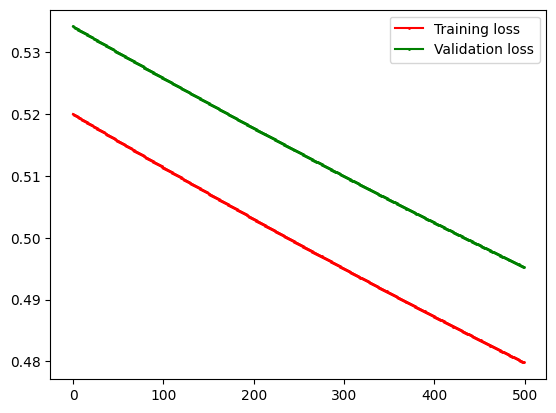

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.7619
Precision : 0.8038
Recall    : 0.7559
F1-score  : 0.7791


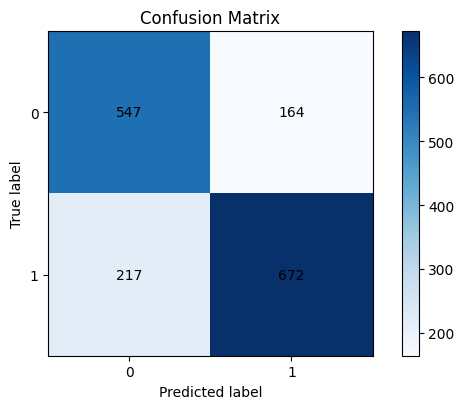

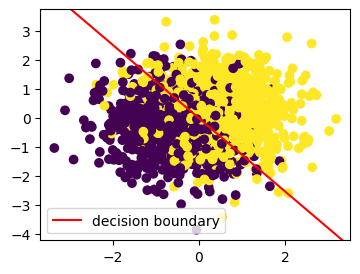

In [139]:
train_model(tgt_data="C",lr=0.001,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

### (C) Different number of iterations under lr = 0.01
#### 500 iterations

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.5606219350797434, Val loss:0.5751465948560307
100. Training loss: 0.5137800194679581, Val loss:0.5298645684047312
150. Training loss: 0.47539411608103216, Val loss:0.4926272287317742
200. Training loss: 0.4437256808205491, Val loss:0.4618010685059735
250. Training loss: 0.41737064521155276, Val loss:0.4360590911646682
300. Training loss: 0.3952211571042462, Val loss:0.41434963550106296
350. Training loss: 0.3764141441390455, Val loss:0.3958516043983783
400. Training loss: 0.36028079821241626, Val loss:0.379928212456391
450. Training loss: 0.34630296779648173, Val loss:0.3660858918425622
500. Training loss: 0.33407794638257704, Val loss:0.3539407406147505


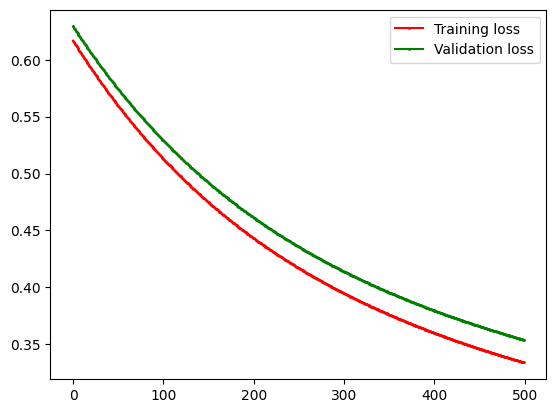

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.9137
Precision : 0.9321
Recall    : 0.9111
F1-score  : 0.9215


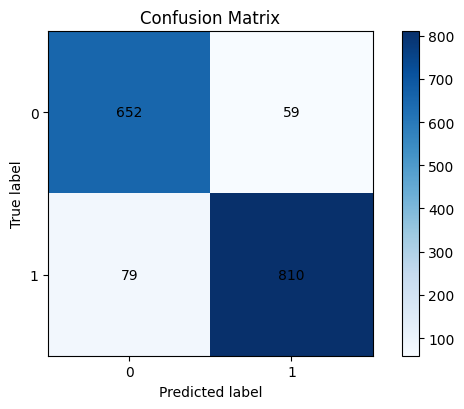

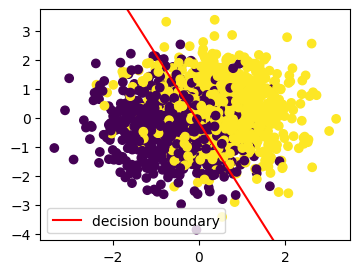

In [140]:
train_model(tgt_data="C",lr=0.01,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### 1000 iterations

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.5073984528468973, Val loss:0.5104741530135616
100. Training loss: 0.47043128392607053, Val loss:0.47590920427065
150. Training loss: 0.4399153847755247, Val loss:0.44736728623776545
200. Training loss: 0.4144853128574829, Val loss:0.423560724312653
250. Training loss: 0.3930713444586484, Val loss:0.40348538647655185
300. Training loss: 0.37484524699375577, Val loss:0.38636746332927163
350. Training loss: 0.3591683656388033, Val loss:0.371612628079501
400. Training loss: 0.34554772496298236, Val loss:0.3587634902990005
450. Training loss: 0.33360115716327227, Val loss:0.3474661964844546
500. Training loss: 0.3230305084195122, Val loss:0.33744503865846615
550. Training loss: 0.3136014049216467, Val loss:0.3284834420717684
600. Training loss: 0.30512809107315436, Val loss:0.3204098098405095
650. Training loss: 0.2974620899426482, Val loss:0.3130869846789592
700. Training loss: 0.2904837069574499, Val loss:0.3064043779635166
750. Tr

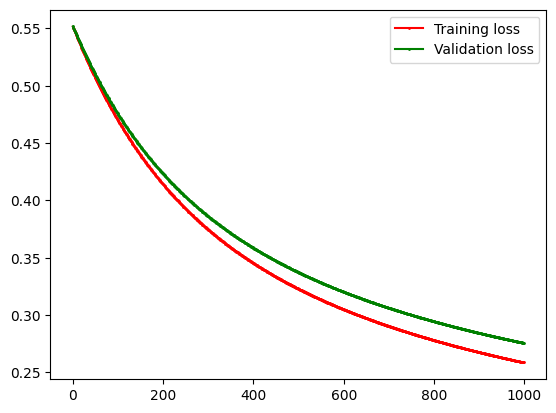

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.9719
Precision : 0.9851
Recall    : 0.9640
F1-score  : 0.9744


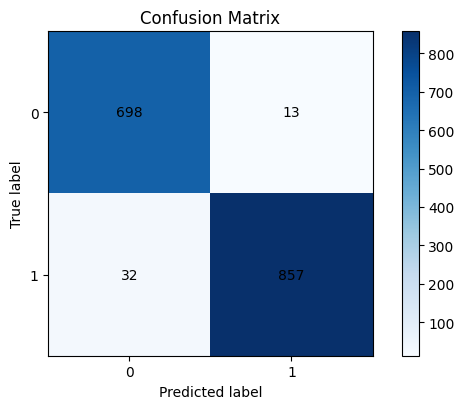

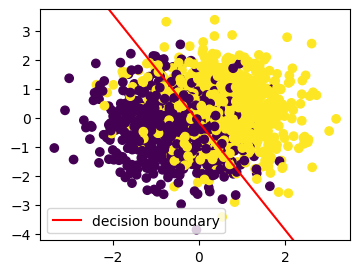

In [141]:
train_model(tgt_data="C",lr=0.01,n_iteration = 1000,val_ratio=0.2,draw_scatter=True)

#### 1500 iterations

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.5124689293531285, Val loss:0.5133801886769922
100. Training loss: 0.47317140970886634, Val loss:0.4765715703487346
150. Training loss: 0.43985319729092465, Val loss:0.44535127179638395
200. Training loss: 0.4115647926343119, Val loss:0.4188289162343272
250. Training loss: 0.38747928591070646, Val loss:0.39622820079146737
300. Training loss: 0.3668913878197614, Val loss:0.376888032335068
350. Training loss: 0.3492086403533287, Val loss:0.36025461602687575
400. Training loss: 0.3339387006098594, Val loss:0.345869013133562
450. Training loss: 0.32067534269005743, Val loss:0.33335335890577217
500. Training loss: 0.30908482007438953, Val loss:0.32239758988256195
550. Training loss: 0.2988934755040148, Val loss:0.3127475678471156
600. Training loss: 0.28987697059549156, Val loss:0.3041948994074061
650. Training loss: 0.28185119256199737, Val loss:0.2965684338846249
700. Training loss: 0.27466472488781335, Val loss:0.28972727614620475


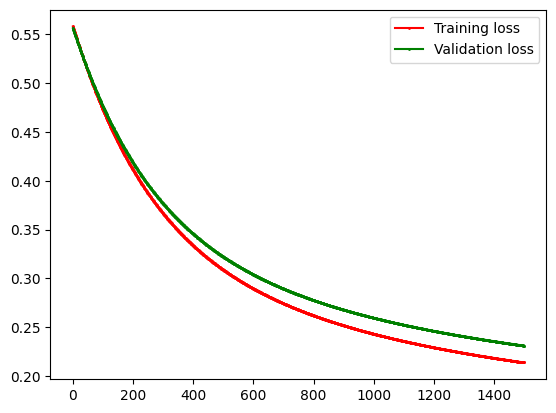

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.9762
Precision : 0.9885
Recall    : 0.9685
F1-score  : 0.9784


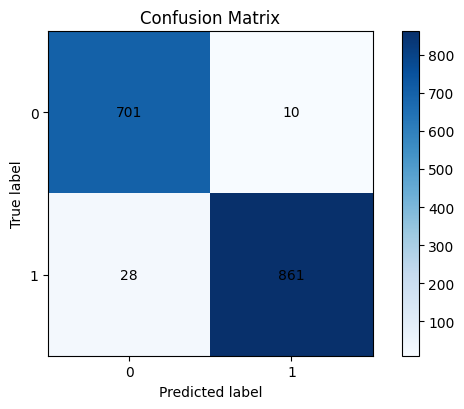

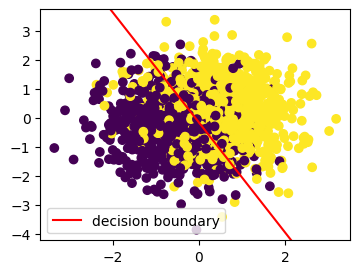

In [142]:
train_model(tgt_data="C",lr=0.01,n_iteration = 1500,val_ratio=0.2,draw_scatter=True)

### Logistic dataset D
#### lr = 0.1`

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.337578227892806, Val loss:0.3512483233867333
100. Training loss: 0.28084537362759815, Val loss:0.298655792908908
150. Training loss: 0.25313896714881107, Val loss:0.2724448664376338
200. Training loss: 0.2358759870982242, Val loss:0.255842702618016
250. Training loss: 0.22380340213341254, Val loss:0.24408721211267417
300. Training loss: 0.21478348613507356, Val loss:0.2352236083618302
350. Training loss: 0.20774588389879517, Val loss:0.22826121356415352
400. Training loss: 0.2020821831853013, Val loss:0.22262975660186549
450. Training loss: 0.1974160845077655, Val loss:0.21797242491728683
500. Training loss: 0.19350034851178158, Val loss:0.21405245771452197


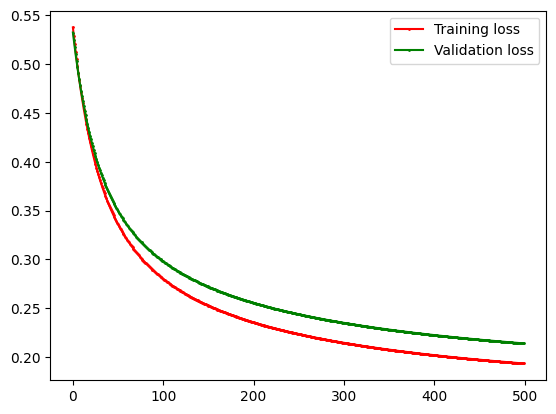

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.9225
Precision : 0.9330
Recall    : 0.9266
F1-score  : 0.9298


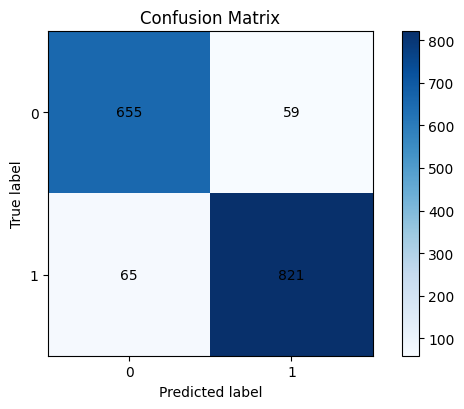

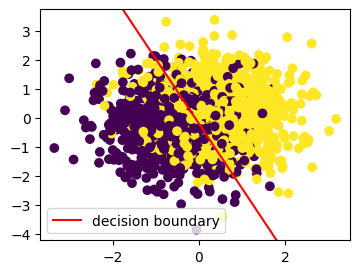

In [143]:
train_model(tgt_data="D",lr=0.1,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.01

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.4910786188498939, Val loss:0.49260212456234387
100. Training loss: 0.4606229696598178, Val loss:0.46425288368089007
150. Training loss: 0.4353168924500851, Val loss:0.4407669365090497
200. Training loss: 0.4140879134766452, Val loss:0.4211147298893302
250. Training loss: 0.3960994055910672, Val loss:0.4044971332689733
300. Training loss: 0.3807025370629139, Val loss:0.39029736770016477
350. Training loss: 0.36739451475732654, Val loss:0.37803956433464236
400. Training loss: 0.35578464920647396, Val loss:0.3673554012511578
450. Training loss: 0.3455678071591112, Val loss:0.35795822885361206
500. Training loss: 0.33650409104036416, Val loss:0.3496234101417626


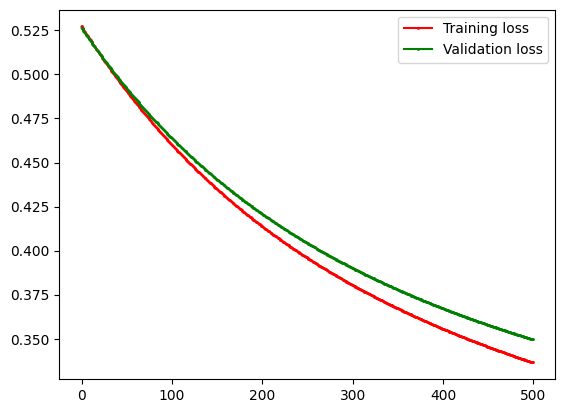

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.8981
Precision : 0.9199
Recall    : 0.8939
F1-score  : 0.9067


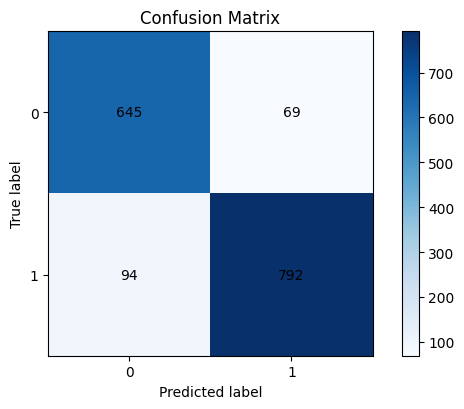

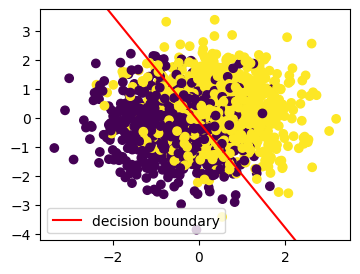

In [144]:
train_model(tgt_data="D",lr=0.01,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.001

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.5329244359205589, Val loss:0.5332204974412043
100. Training loss: 0.5288041931789946, Val loss:0.5293431963470379
150. Training loss: 0.5247663532301637, Val loss:0.5255448480552072
200. Training loss: 0.5208090273493855, Val loss:0.5218236085684537
250. Training loss: 0.5169303632530161, Val loss:0.5181776696676555
300. Training loss: 0.5131285451493797, Val loss:0.5146052590601853
350. Training loss: 0.5094017937213952, Val loss:0.5111046404476793
400. Training loss: 0.5057483660461429, Val loss:0.5076741135190955
450. Training loss: 0.5021665554564024, Val loss:0.5043120138747781
500. Training loss: 0.498654691348971, Val loss:0.5010167128870895


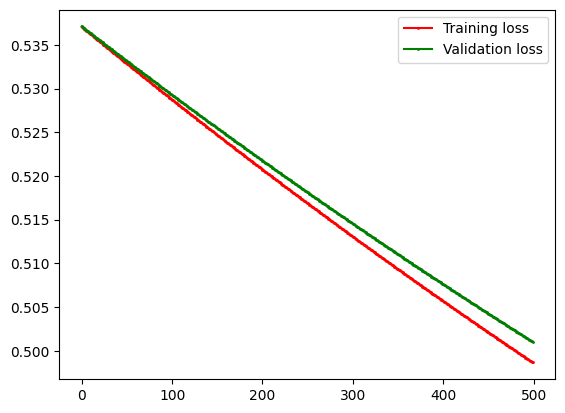

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.7719
Precision : 0.8173
Recall    : 0.7573
F1-score  : 0.7862


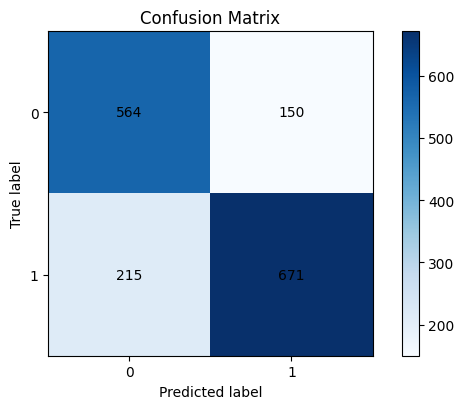

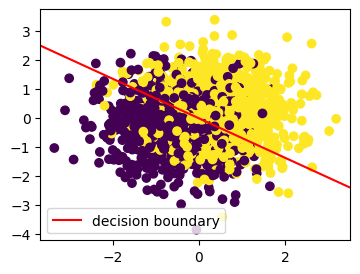

In [145]:
train_model(tgt_data="D",lr=0.001,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

### (D) Different number of iterations under lr = 0.01
#### 500 iterations

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.5355659243082143, Val loss:0.5395013141729175
100. Training loss: 0.4960699369900484, Val loss:0.5023069494090797
150. Training loss: 0.463040249167687, Val loss:0.47123251931054905
200. Training loss: 0.43534148521845156, Val loss:0.4451841798468477
250. Training loss: 0.4120117652194879, Val loss:0.42324233760599617
300. Training loss: 0.3922528088019665, Val loss:0.40465034784051407
350. Training loss: 0.37541155992350783, Val loss:0.38879329285342545
400. Training loss: 0.3609586487979117, Val loss:0.37517468898788076
450. Training loss: 0.3484671183454912, Val loss:0.36339483050715815
500. Training loss: 0.33759326135488216, Val loss:0.3531320871876898


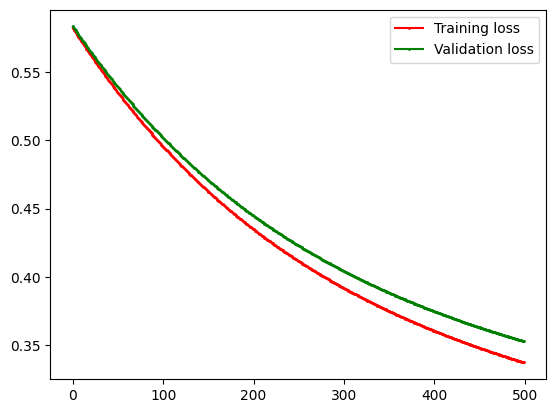

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.8769
Precision : 0.8992
Recall    : 0.8758
F1-score  : 0.8874


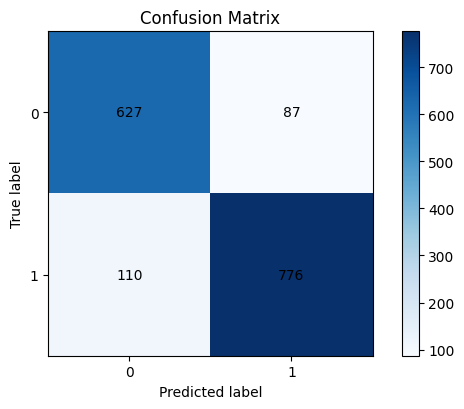

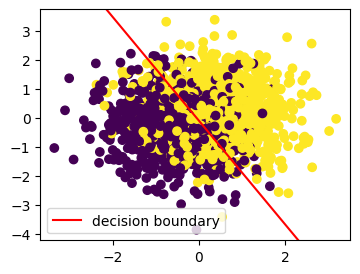

In [146]:
train_model(tgt_data="D",lr=0.01,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### 1000 iterations

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.4178270858870864, Val loss:0.4289490166811364
100. Training loss: 0.3982125385118266, Val loss:0.4104723750966823
150. Training loss: 0.38155339102155394, Val loss:0.39476831086864095
200. Training loss: 0.3672743638348211, Val loss:0.3812985593405112
250. Training loss: 0.35492470472720183, Val loss:0.369641221979016
300. Training loss: 0.34415054408513546, Val loss:0.3594647340835082
350. Training loss: 0.33467294102516554, Val loss:0.3505073879652049
400. Training loss: 0.32627082337646324, Val loss:0.3425614930119772
450. Training loss: 0.3187678842895224, Val loss:0.3354612228058332
500. Training loss: 0.3120225703025023, Val loss:0.3290733200668283
550. Training loss: 0.3059204395583329, Val loss:0.323289986771967
600. Training loss: 0.30036831938712527, Val loss:0.31802343397353827
650. Training loss: 0.2952898242865006, Val loss:0.31320168915630436
700. Training loss: 0.29062190191212206, Val loss:0.30876535674199274
750

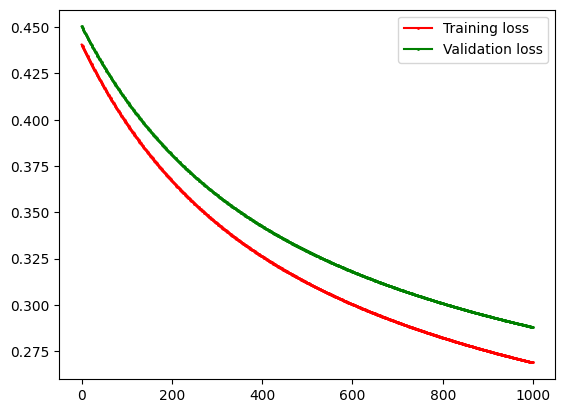

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.9213
Precision : 0.9338
Recall    : 0.9233
F1-score  : 0.9285


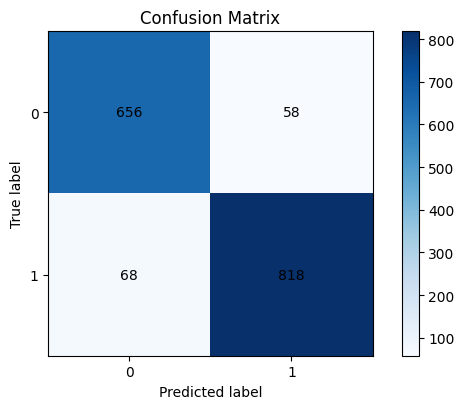

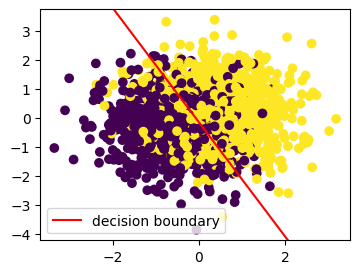

In [147]:
train_model(tgt_data="D",lr=0.01,n_iteration = 1000,val_ratio=0.2,draw_scatter=True)

#### 1500 iterations

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.4772830917314902, Val loss:0.4809371193920195
100. Training loss: 0.44882516627553315, Val loss:0.45442384981584977
150. Training loss: 0.4251074497143453, Val loss:0.4323332856525769
200. Training loss: 0.4051502083982772, Val loss:0.41375234172975794
250. Training loss: 0.3881907902231836, Val loss:0.39797066147374494
300. Training loss: 0.3736373557307477, Val loss:0.3844364150663352
350. Training loss: 0.3610300715126872, Val loss:0.3727200947015311
400. Training loss: 0.3500102616789845, Val loss:0.3624860386035743
450. Training loss: 0.340296572423219, Val loss:0.35347050282014875
500. Training loss: 0.3316668236718205, Val loss:0.34546495321139553
550. Training loss: 0.3239442820825098, Val loss:0.3383033913120869
600. Training loss: 0.3169872956055251, Val loss:0.33185274645857393
650. Training loss: 0.31068145501106137, Val loss:0.32600557952431275
700. Training loss: 0.3049336457963731, Val loss:0.3206745235514591
750.

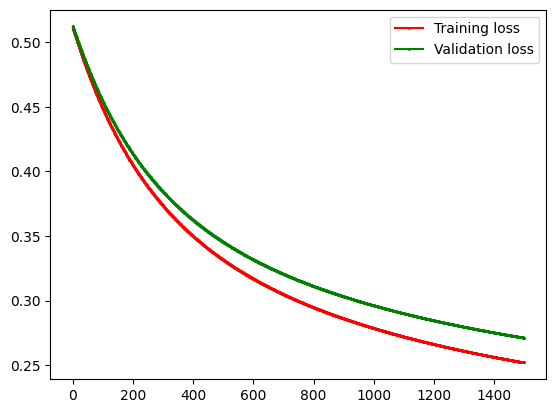

Logistic Regression Evaluation on dataset {tgt_data} dataset, lr = {lr}
Accuracy  : 0.9244
Precision : 0.9381
Recall    : 0.9244
F1-score  : 0.9312


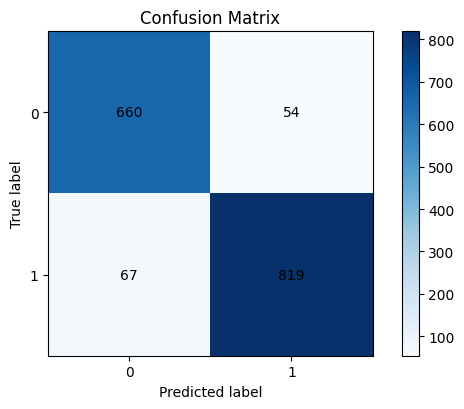

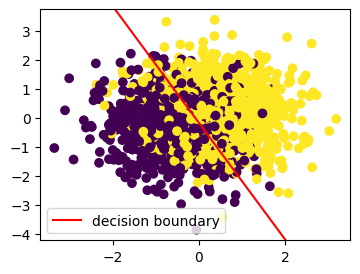

In [148]:
train_model(tgt_data="D",lr=0.01,n_iteration = 1500,val_ratio=0.2,draw_scatter=True)

In [149]:
# # Train the model
# from model.linear_model import LinearModel

# seed = 42 # do not change the seed
# np.random.seed(seed)

# # Setting loss function, gradient, and activation function.
# loss_fn = logloss
# act_fn = sigmoid
# grad_fn = logloss_sigmoid_grad

# # Split dataset to train dataset and validation dataset
# X_train,y_train,X_val,y_val = get_train_val(X,y)

# # Setting model and starting training
# model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
# model.fit(X_train,y_train,lr=0.01,n_iteration =500,val_ratio=0.2)

In [150]:
# # Get the Prediction
# y_val_pred = model.predict(X_val)

In [151]:
# # Evaluation
# # Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
# evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

Plot validation set and decision boundary

In [152]:
# # Plot
# x_min, x_max = X_val[:, 1].min(), X_val[:, 1].max()
# y_min, y_max = X_val[:, 2].min(), X_val[:, 2].max()

# # Add a small margin so points/boundary are not flush with axes
# x_margin = 0.05 * (x_max - x_min)
# y_margin = 0.05 * (y_max - y_min)

# x_plot_min, x_plot_max = x_min - x_margin, x_max + x_margin
# y_plot_min, y_plot_max = y_min - y_margin, y_max + y_margin

# plt.scatter(X_val[:, 1], X_val[:, 2], c=y_val)

# # Decision boundary from model weights: w0 + w1*x1 + w2*x2 = 0
# ex1 = np.linspace(x_plot_min, x_plot_max, 200)
# ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

# plt.plot(ex1, ex2, color='r', label='decision boundary')
# plt.xlim(x_plot_min, x_plot_max)
# plt.ylim(y_plot_min, y_plot_max)
# plt.legend()
# plt.show()